# MACHINE LEARNING 2026 - FINAL PROJECT (Option 1)

Course 2025/26: *C. Sun*, *M. Pavan*, *P. Zanuttigh*  

**Group Members:**        
*`Tommaso Dambi ID:2141118`*         
*`Alessandro Costabile ID:2146702`*        
*`Carlo Toffoli ID:2144522`*

## Heart Disease Analysis Using Clustering and Classification
The dataset labels are the following:

|   id| age   | sex | dataset | cp | trestbps | chol | fbs | restecg | thalch | exang | oldpeak |slope | ca | thal | num |
| :-: | :-:  |  :-: | :-: | :-:| :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: |
| 1  |  63   | Male | Cleveland | typical angina | 145 | 233 | TRUE | Iv hypertrophy | 150 | FALSE | 2.3 | downsloping | 0 | fixed defect | 0 |
| 2  | 67   | Male | Cleveland | asymptomatic | 160 | 286 | FALSE | Iv hypertrophy | 108 | TRUE | 1.5 | flat | 3 | normal | 1 |
| 3   | 67 | Male | Cleveland | asymptomatic | 120 | 229 | FALSE | Iv hypertrophy | 129 | TRUE | 2.6 | flat | 2 | reversable | 2 |
| 4   | 37| Male | Cleveland | non-anginal | 130 | 250 | FALSE | normal | 187 | FALSE | 3.5 | downsloping | 0 | normal | 3 |

Description of the features:
 - `cp`: chest pain type:
    1. typical angina
    2. atypical angina
    3. non-anginal pain
    4. asymptomatic
 - `trestbps`: resting blood pressure (in mm Hg on admission to the hospital)
 - `chol`: serum cholestoral [mg/dL]
 - `fbs`: fasting blood sugar (True if above 120 mg/dL)
 - `restecg`: resting electrocardiographic results
    1. having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    2. showing probable or definite left ventricular hypertrophy by Estes' criteria
    3. normal
 - `thalch`: maximum heart rate achieved
 - `exang`: exercise induced angina
    1. yes
    2. no
 - `oldpeak`: ST depression induced by exercise relative to rest
 - `slope`: the slope of the peak exercise ST segment
    1. upsloping
    2. flat
    3. downsloping
 - `ca`: number of major vessels (0-3) colored by flouroscopy
 - `thal`: type of defect in blood flow towards heart
    1. fixed defect
    2. reversable
    3. normal
 - `num`: label - severity of the disease from 0 (not present) to 4 (max severity)

Some records lack of data of some features such as `trestbps`, `chol`, `fbs`, `thalch`, `exang`, `oldpeak`, `ca`. This has to be addressed, maybe with clustering?

# ⚠️ Attenzione
Il dataset non è incluso per ovvi motivi nel repository github. Scaricalo, estrailo e mettilo nella cartella `/data`. Ricorda di aggiornare il nome del file!

# CODE

In [1]:
from util import accuracy, pca_decomposition, plot_clusters
from clustering import algo_showcase, build_dataframe
from preproc import Preprocess

from sklearn.metrics import precision_score as precision
from sklearn.cluster import KMeans, AgglomerativeClustering
import pandas as pd
import numpy as np

ID = 2146702

## 0. Preliminary analysis
This was useful to highlight some issues with the dataset, such as the missing values and how the different features were correlated.
Later, during the development of the preprocessing code, we used the `pairplot` function shipped with seaborn to get an idea of how different encoding solutions affected the distribution.

In [ ]:
from seaborn import pairplot, heatmap

data = Preprocess()
df = pd.DataFrame(data.X)
df['num'] = data.Y

pairplot(df, hue="num", corner=True)
# plt.savefig("pairplot_onehot.jpg")

heatmap(data=df.corr(), cmap="crest")
# plt.savefig("heatmap.jpg")

## 1. Data Preprocessing
All the preprocessing helper functions are defined in `preproc.py`.
As many samples lack the significant `ca` feature we have decided to use just the Cleveland data which provides that feature in almost all the samples.

## 2. Clustering analysis

Dataset is float64 (299, 13)
Scores - also with inverted labels
Accuracy: 20.74 | 79.26 %
Precision: 22.3 | 77.7 %


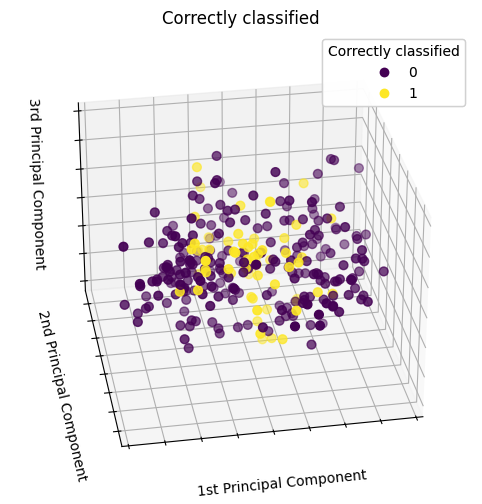

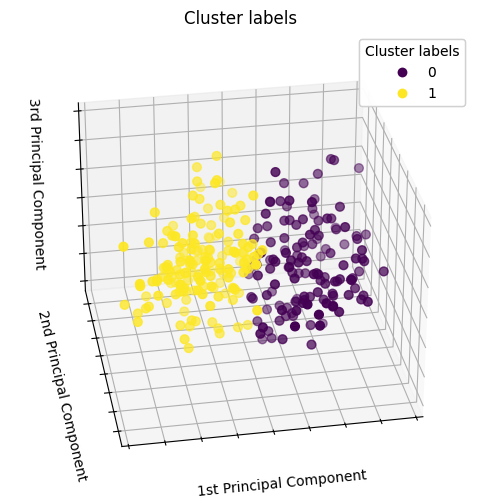

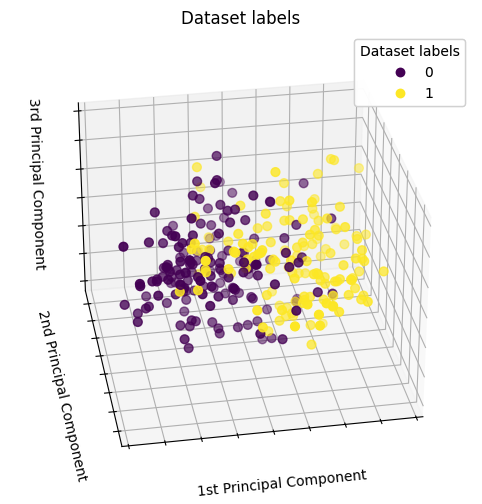

PCA weights of first component (most significant):
[-0.31300404  0.10076538  0.34119149 -0.18609912 -0.08793466 -0.06679939
  0.12404625  0.4064058  -0.33613438 -0.39811721 -0.36296507 -0.31028829
  0.22040051]
Cluster centers (in feature space):
[[ 0.44886729 -0.1791869  -0.52556892  0.20282333  0.07898048  0.06171255
  -0.16410728 -0.67121487  0.58055015  0.63998576  0.69387517  0.38865511
  -0.28270718]
 [-0.38995346  0.15566862  0.456588   -0.17620277 -0.06861429 -0.05361278
   0.1425682   0.58311792 -0.50435294 -0.55598763 -0.60280405 -0.33764413
   0.24560186]]


In [3]:
data = Preprocess(
    dropped=['dataset'],
    ordinal=True,
    encoded_features=[1,2,6,10,12],
    permute_map=True,
    permute_data=True,
    multiclass=False,
    random_state=ID
)


clustering = KMeans(2, n_init=10, random_state=ID).fit(data.X)

labels = clustering.labels_

print("Scores - also with inverted labels")
print(f"Accuracy: {round(accuracy(labels, data.Y)*100, 2)} | {round((1-accuracy(labels, data.Y))*100, 2)} %")
print(f"Precision: {round(precision(labels, data.Y)*100, 2)} | {round((1-precision(labels, data.Y))*100, 2)} %")

X_reduced, components = pca_decomposition(data.X)

plot_clusters(X_reduced, (data.Y == labels).astype(int), "Correctly classified")
plot_clusters(X_reduced, labels, "Cluster labels")
plot_clusters(X_reduced, data.Y, "Dataset labels")

print("PCA weights of first component (most significant):")
print(components[0])

print("Cluster centers (in feature space):")
print(clustering.cluster_centers_)

### Optimal number of cluster search

In [ ]:
pd.set_option('display.max_columns', None)

data = Preprocess(
    dropped=['dataset'],
    ordinal=True,
    encoded_features=[1,2,6,10,12],
    permute_map=True,
    permute_data=True,
    multiclass=True,
    random_state=ID
)

algo = KMeans(n_init=1, random_state = ID)
# algo = AgglomerativeClustering(linkage='ward')

for df in algo_showcase(data, range(6,10), algo, head=1):
    df.set_index('cluster n°', inplace=True)
    display(df)

Dataset is float64 (299, 13)


Number of clusters: 6
Risk variance: 1.00
Risk maxima: 0.39


,risk fom,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
cluster n°,,,,,,,,,,,,,,
5,0.387,"(35.0, 70.0, 57.169)","(0.0, 1.0, 0.169)","(0.0, 3.0, 1.123)","(110.0, 180.0, 135.677)","(100.0, 409.0, 252.046)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.492)","(88.0, 182.0, 129.123)","(0.0, 1.0, 0.708)","(0.0, 6.2, 2.238)","(0.0, 2.0, 1.8)","(0.0, 3.0, 1.231)","(0.0, 1.0, 0.092)"
1,0.205,"(35.0, 71.0, 52.414)","(1.0, 1.0, 1.0)","(0.0, 3.0, 1.948)","(94.0, 180.0, 130.017)","(141.0, 564.0, 262.724)","(0.0, 1.0, 0.017)","(0.0, 1.0, 0.552)","(122.0, 182.0, 160.759)","(0.0, 1.0, 0.103)","(0.0, 1.6, 0.426)","(0.0, 2.0, 0.741)","(0.0, 2.0, 0.224)","(0.0, 1.0, 0.966)"
0,0.178,"(29.0, 70.0, 47.956)","(0.0, 1.0, 0.022)","(2.0, 3.0, 2.644)","(101.0, 192.0, 127.933)","(157.0, 335.0, 241.0)","(0.0, 1.0, 0.067)","(0.0, 1.0, 0.733)","(123.0, 202.0, 168.044)","(0.0, 1.0, 0.044)","(0.0, 3.5, 0.338)","(0.0, 2.0, 0.222)","(0.0, 1.0, 0.089)","(0.0, 2.0, 0.844)"
4,0.151,"(34.0, 68.0, 51.154)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.038)","(94.0, 170.0, 128.865)","(149.0, 303.0, 233.308)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.462)","(111.0, 190.0, 160.923)","(0.0, 1.0, 0.192)","(0.0, 3.2, 0.556)","(0.0, 2.0, 0.596)","(0.0, 3.0, 0.481)","(0.0, 2.0, 0.404)"
2,0.092,"(43.0, 71.0, 58.359)","(0.0, 1.0, 0.282)","(0.0, 3.0, 1.41)","(108.0, 200.0, 141.385)","(126.0, 417.0, 250.231)","(1.0, 1.0, 1.0)","(0.0, 1.0, 0.359)","(90.0, 178.0, 146.41)","(0.0, 1.0, 0.359)","(0.0, 4.0, 1.169)","(0.0, 2.0, 1.0)","(0.0, 3.0, 1.128)","(0.0, 2.0, 0.718)"
3,0.091,"(42.0, 77.0, 61.3)","(0.0, 1.0, 0.375)","(0.0, 3.0, 1.075)","(100.0, 174.0, 126.275)","(149.0, 318.0, 235.8)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.55)","(71.0, 169.0, 132.3)","(0.0, 1.0, 0.525)","(0.0, 4.4, 1.415)","(0.0, 2.0, 1.475)","(0.0, 3.0, 0.875)","(1.0, 2.0, 1.275)"




Number of clusters: 7
Risk variance: 0.49
Risk maxima: 0.31


,risk fom,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
cluster n°,,,,,,,,,,,,,,
6,0.312,"(45.0, 77.0, 60.341)","(0.0, 1.0, 0.136)","(0.0, 3.0, 1.182)","(100.0, 178.0, 136.136)","(164.0, 409.0, 269.795)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.341)","(95.0, 173.0, 135.159)","(0.0, 1.0, 0.545)","(0.0, 6.2, 2.393)","(0.0, 2.0, 1.75)","(0.0, 3.0, 1.977)","(0.0, 2.0, 0.295)"
1,0.181,"(34.0, 71.0, 51.745)","(1.0, 1.0, 1.0)","(0.0, 3.0, 2.078)","(94.0, 160.0, 128.549)","(141.0, 360.0, 249.961)","(0.0, 1.0, 0.02)","(0.0, 1.0, 0.627)","(133.0, 192.0, 162.804)","(0.0, 1.0, 0.039)","(0.0, 1.6, 0.414)","(0.0, 2.0, 0.569)","(0.0, 2.0, 0.275)","(0.0, 1.0, 0.98)"
0,0.175,"(29.0, 70.0, 48.273)","(0.0, 0.0, 0.0)","(2.0, 3.0, 2.636)","(101.0, 192.0, 128.159)","(157.0, 335.0, 241.705)","(0.0, 1.0, 0.068)","(0.0, 1.0, 0.727)","(123.0, 202.0, 167.5)","(0.0, 1.0, 0.045)","(0.0, 3.5, 0.33)","(0.0, 2.0, 0.227)","(0.0, 1.0, 0.091)","(0.0, 2.0, 0.841)"
4,0.160,"(34.0, 68.0, 51.12)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.0)","(94.0, 170.0, 128.64)","(149.0, 303.0, 233.8)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.48)","(125.0, 190.0, 161.76)","(0.0, 1.0, 0.16)","(0.0, 2.0, 0.514)","(0.0, 2.0, 0.58)","(0.0, 3.0, 0.5)","(0.0, 2.0, 0.46)"
5,0.126,"(35.0, 70.0, 54.474)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.053)","(100.0, 152.0, 125.947)","(100.0, 309.0, 215.895)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.474)","(71.0, 182.0, 124.421)","(0.0, 1.0, 0.868)","(0.0, 5.6, 1.832)","(0.0, 2.0, 1.579)","(0.0, 1.0, 0.421)","(0.0, 2.0, 0.474)"
2,0.092,"(43.0, 71.0, 58.359)","(0.0, 1.0, 0.282)","(0.0, 3.0, 1.41)","(108.0, 200.0, 141.385)","(126.0, 417.0, 250.231)","(1.0, 1.0, 1.0)","(0.0, 1.0, 0.359)","(90.0, 178.0, 146.41)","(0.0, 1.0, 0.359)","(0.0, 4.0, 1.169)","(0.0, 2.0, 1.0)","(0.0, 3.0, 1.128)","(0.0, 2.0, 0.718)"
3,0.090,"(42.0, 76.0, 60.061)","(0.0, 1.0, 0.848)","(0.0, 3.0, 1.152)","(100.0, 180.0, 135.333)","(149.0, 564.0, 269.152)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.667)","(97.0, 169.0, 136.455)","(0.0, 1.0, 0.485)","(0.0, 3.4, 1.052)","(0.0, 2.0, 1.667)","(0.0, 2.0, 0.333)","(0.0, 2.0, 0.939)"




Number of clusters: 8
Risk variance: 0.33
Risk maxima: 0.23


,risk fom,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
cluster n°,,,,,,,,,,,,,,
7,0.228,"(45.0, 77.0, 61.5)","(0.0, 1.0, 0.214)","(0.0, 3.0, 1.214)","(100.0, 160.0, 136.75)","(164.0, 409.0, 263.929)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.286)","(108.0, 173.0, 136.786)","(0.0, 1.0, 0.536)","(0.0, 6.2, 2.479)","(0.0, 2.0, 1.679)","(1.0, 3.0, 2.464)","(0.0, 2.0, 0.464)"
4,0.189,"(35.0, 70.0, 54.234)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.979)","(100.0, 152.0, 125.021)","(100.0, 353.0, 231.979)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.574)","(71.0, 182.0, 123.021)","(0.0, 1.0, 0.894)","(0.0, 5.6, 1.774)","(0.0, 2.0, 1.66)","(0.0, 2.0, 0.596)","(0.0, 2.0, 0.426)"
1,0.181,"(34.0, 74.0, 52.451)","(1.0, 1.0, 1.0)","(1.0, 3.0, 2.137)","(94.0, 160.0, 127.608)","(141.0, 360.0, 253.882)","(0.0, 1.0, 0.02)","(0.0, 1.0, 0.608)","(121.0, 192.0, 161.451)","(0.0, 1.0, 0.078)","(0.0, 1.6, 0.384)","(0.0, 2.0, 0.569)","(0.0, 2.0, 0.294)","(0.0, 1.0, 0.98)"
3,0.165,"(29.0, 65.0, 44.659)","(0.0, 1.0, 0.023)","(0.0, 3.0, 1.477)","(108.0, 152.0, 126.955)","(149.0, 321.0, 234.159)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.477)","(126.0, 202.0, 169.341)","(0.0, 1.0, 0.091)","(0.0, 3.5, 0.434)","(0.0, 2.0, 0.273)","(0.0, 3.0, 0.318)","(0.0, 2.0, 0.932)"
0,0.104,"(41.0, 70.0, 53.25)","(0.0, 0.0, 0.0)","(1.0, 3.0, 2.325)","(94.0, 192.0, 129.175)","(126.0, 335.0, 232.45)","(0.0, 1.0, 0.15)","(0.0, 1.0, 0.9)","(123.0, 195.0, 163.9)","(0.0, 1.0, 0.15)","(0.0, 1.6, 0.302)","(0.0, 2.0, 0.125)","(0.0, 2.0, 0.375)","(0.0, 1.0, 0.475)"
2,0.092,"(43.0, 71.0, 58.861)","(0.0, 1.0, 0.306)","(0.0, 3.0, 1.361)","(108.0, 200.0, 140.778)","(176.0, 417.0, 254.972)","(1.0, 1.0, 1.0)","(0.0, 1.0, 0.306)","(90.0, 178.0, 144.444)","(0.0, 1.0, 0.389)","(0.0, 4.0, 1.247)","(0.0, 2.0, 1.083)","(0.0, 3.0, 1.139)","(0.0, 2.0, 0.75)"
5,0.073,"(42.0, 76.0, 59.741)","(0.0, 1.0, 0.963)","(0.0, 2.0, 1.037)","(100.0, 180.0, 136.852)","(149.0, 394.0, 252.37)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.778)","(97.0, 171.0, 137.185)","(0.0, 1.0, 0.444)","(0.0, 3.4, 1.041)","(0.0, 2.0, 1.741)","(0.0, 2.0, 0.333)","(0.0, 2.0, 0.852)"
6,0.065,"(46.0, 67.0, 58.808)","(0.0, 1.0, 0.038)","(0.0, 3.0, 1.269)","(112.0, 178.0, 140.538)","(185.0, 564.0, 267.462)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.077)","(103.0, 171.0, 149.692)","(0.0, 1.0, 0.077)","(0.0, 4.2, 1.535)","(0.0, 2.0, 1.615)","(0.0, 2.0, 0.385)","(0.0, 2.0, 0.269)"




Number of clusters: 9
Risk variance: 0.32
Risk maxima: 0.26


,risk fom,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
cluster n°,,,,,,,,,,,,,,
7,0.264,"(45.0, 77.0, 60.0)","(0.0, 1.0, 0.212)","(1.0, 2.0, 1.152)","(110.0, 200.0, 138.758)","(164.0, 409.0, 273.545)","(0.0, 1.0, 0.091)","(0.0, 1.0, 0.273)","(95.0, 173.0, 134.394)","(0.0, 1.0, 0.667)","(0.0, 6.2, 2.567)","(0.0, 2.0, 1.636)","(0.0, 3.0, 2.242)","(0.0, 1.0, 0.152)"
0,0.129,"(34.0, 68.0, 49.08)","(0.0, 1.0, 0.14)","(1.0, 3.0, 2.44)","(94.0, 172.0, 122.42)","(126.0, 325.0, 222.28)","(0.0, 1.0, 0.2)","(0.0, 1.0, 0.9)","(123.0, 194.0, 163.74)","(0.0, 1.0, 0.06)","(0.0, 1.6, 0.308)","(0.0, 2.0, 0.12)","(0.0, 2.0, 0.16)","(0.0, 2.0, 0.74)"
3,0.127,"(29.0, 65.0, 47.075)","(0.0, 1.0, 0.025)","(0.0, 3.0, 1.45)","(110.0, 192.0, 131.525)","(149.0, 321.0, 240.425)","(0.0, 1.0, 0.025)","(0.0, 1.0, 0.3)","(126.0, 202.0, 171.3)","(0.0, 1.0, 0.05)","(0.0, 3.5, 0.495)","(0.0, 2.0, 0.25)","(0.0, 3.0, 0.6)","(0.0, 2.0, 0.825)"
8,0.109,"(40.0, 70.0, 57.0)","(0.0, 1.0, 0.2)","(0.0, 2.0, 1.067)","(108.0, 180.0, 138.067)","(174.0, 353.0, 253.567)","(0.0, 1.0, 0.367)","(0.0, 2.0, 0.667)","(88.0, 178.0, 140.767)","(0.0, 1.0, 0.933)","(0.0, 3.1, 1.117)","(0.0, 2.0, 1.1)","(0.0, 3.0, 0.7)","(0.0, 1.0, 0.067)"
4,0.096,"(35.0, 67.0, 52.407)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.963)","(100.0, 150.0, 119.63)","(100.0, 315.0, 213.259)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.407)","(96.0, 182.0, 126.333)","(1.0, 1.0, 1.0)","(0.0, 5.6, 1.881)","(0.0, 2.0, 1.741)","(0.0, 2.0, 0.481)","(0.0, 2.0, 0.667)"
5,0.093,"(39.0, 71.0, 53.0)","(1.0, 1.0, 1.0)","(1.0, 3.0, 1.828)","(100.0, 174.0, 127.483)","(141.0, 294.0, 227.207)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.552)","(97.0, 175.0, 149.483)","(0.0, 1.0, 0.241)","(0.0, 1.8, 0.669)","(1.0, 2.0, 1.966)","(0.0, 2.0, 0.207)","(0.0, 1.0, 0.966)"
6,0.085,"(39.0, 67.0, 56.571)","(0.0, 0.0, 0.0)","(0.0, 3.0, 1.143)","(110.0, 178.0, 136.536)","(185.0, 302.0, 248.643)","(0.0, 1.0, 0.107)","(0.0, 1.0, 0.286)","(103.0, 178.0, 148.0)","(0.0, 0.0, 0.0)","(0.0, 4.2, 1.486)","(0.0, 2.0, 1.893)","(0.0, 2.0, 0.393)","(0.0, 1.0, 0.25)"
1,0.074,"(41.0, 74.0, 59.0)","(0.0, 1.0, 0.951)","(0.0, 3.0, 1.829)","(102.0, 180.0, 133.902)","(178.0, 564.0, 293.927)","(0.0, 1.0, 0.171)","(0.0, 1.0, 0.488)","(96.0, 179.0, 156.0)","(0.0, 1.0, 0.122)","(0.0, 1.6, 0.312)","(0.0, 2.0, 0.098)","(0.0, 2.0, 0.415)","(0.0, 1.0, 0.951)"
2,0.060,"(55.0, 76.0, 62.857)","(0.0, 1.0, 0.333)","(0.0, 3.0, 1.0)","(114.0, 180.0, 144.762)","(176.0, 327.0, 241.143)","(0.0, 1.0, 0.381)","(0.0, 2.0, 0.762)","(71.0, 151.0, 126.952)","(0.0, 1.0, 0.238)","(0.0, 4.4, 1.833)","(0.0, 2.0, 1.667)","(0.0, 3.0, 1.286)","(0.0, 2.0, 1.476)"


### Cluster analysis and visualization

Risk variance: 1.00
Risk maxima: 0.39


,cluster n°,risk fom,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,5,0.387,"(35.0, 70.0, 57.169)","(0.0, 1.0, 0.169)","(0.0, 3.0, 1.123)","(110.0, 180.0, 135.677)","(100.0, 409.0, 252.046)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.492)","(88.0, 182.0, 129.123)","(0.0, 1.0, 0.708)","(0.0, 6.2, 2.238)","(0.0, 2.0, 1.8)","(0.0, 3.0, 1.231)","(0.0, 1.0, 0.092)"
1,1,0.205,"(35.0, 71.0, 52.414)","(1.0, 1.0, 1.0)","(0.0, 3.0, 1.948)","(94.0, 180.0, 130.017)","(141.0, 564.0, 262.724)","(0.0, 1.0, 0.017)","(0.0, 1.0, 0.552)","(122.0, 182.0, 160.759)","(0.0, 1.0, 0.103)","(0.0, 1.6, 0.426)","(0.0, 2.0, 0.741)","(0.0, 2.0, 0.224)","(0.0, 1.0, 0.966)"
2,0,0.178,"(29.0, 70.0, 47.956)","(0.0, 1.0, 0.022)","(2.0, 3.0, 2.644)","(101.0, 192.0, 127.933)","(157.0, 335.0, 241.0)","(0.0, 1.0, 0.067)","(0.0, 1.0, 0.733)","(123.0, 202.0, 168.044)","(0.0, 1.0, 0.044)","(0.0, 3.5, 0.338)","(0.0, 2.0, 0.222)","(0.0, 1.0, 0.089)","(0.0, 2.0, 0.844)"
3,4,0.151,"(34.0, 68.0, 51.154)","(0.0, 0.0, 0.0)","(0.0, 2.0, 1.038)","(94.0, 170.0, 128.865)","(149.0, 303.0, 233.308)","(0.0, 0.0, 0.0)","(0.0, 1.0, 0.462)","(111.0, 190.0, 160.923)","(0.0, 1.0, 0.192)","(0.0, 3.2, 0.556)","(0.0, 2.0, 0.596)","(0.0, 3.0, 0.481)","(0.0, 2.0, 0.404)"
4,2,0.092,"(43.0, 71.0, 58.359)","(0.0, 1.0, 0.282)","(0.0, 3.0, 1.41)","(108.0, 200.0, 141.385)","(126.0, 417.0, 250.231)","(1.0, 1.0, 1.0)","(0.0, 1.0, 0.359)","(90.0, 178.0, 146.41)","(0.0, 1.0, 0.359)","(0.0, 4.0, 1.169)","(0.0, 2.0, 1.0)","(0.0, 3.0, 1.128)","(0.0, 2.0, 0.718)"
5,3,0.091,"(42.0, 77.0, 61.3)","(0.0, 1.0, 0.375)","(0.0, 3.0, 1.075)","(100.0, 174.0, 126.275)","(149.0, 318.0, 235.8)","(0.0, 0.0, 0.0)","(0.0, 2.0, 0.55)","(71.0, 169.0, 132.3)","(0.0, 1.0, 0.525)","(0.0, 4.4, 1.415)","(0.0, 2.0, 1.475)","(0.0, 3.0, 0.875)","(1.0, 2.0, 1.275)"


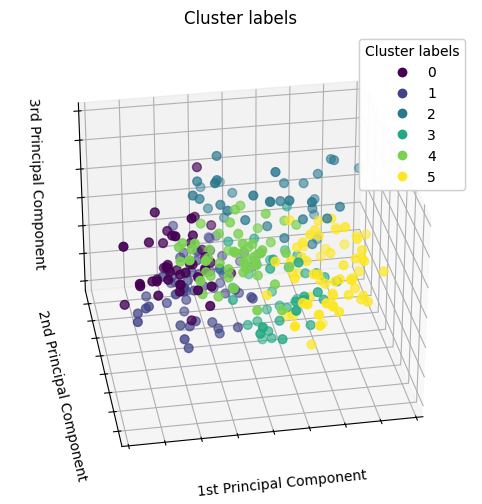

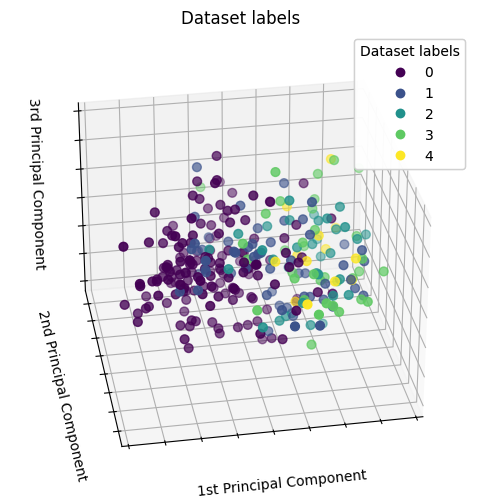

PCA weights:
[[-0.31300404  0.10076538  0.34119149 -0.18609912 -0.08793466 -0.06679939
   0.12404625  0.4064058  -0.33613438 -0.39811721 -0.36296507 -0.31028829
   0.22040051]
 [ 0.40179879  0.39706626  0.12084878  0.38628812  0.43540205  0.30234767
  -0.23541707  0.10672526 -0.24181711 -0.10384259 -0.13839727  0.18962693
   0.21190014]
 [ 0.09628364  0.58078276  0.08050394 -0.17556627  0.12387883 -0.46101441
   0.29146616 -0.277701    0.01958757  0.05993811  0.32805002 -0.1729497
   0.29096591]]


In [ ]:
n_clusters = 6

algo.set_params(n_clusters = n_clusters)
algo.fit(data.X)

display(build_dataframe(data, algo.labels_, n_clusters))

X_reduced, components = pca_decomposition(data.X)

plot_clusters(X_reduced, algo.labels_, "Cluster labels")
plot_clusters(X_reduced, data.Y, "Dataset labels")

print("PCA weights:")
print(components)

## 3. Supervised Learning

In [76]:
from sklearn.model_selection import train_test_split
from time import time

ID = 1779718031

data = Preprocess(
    dropped=[],
    encoded_features=[1,2,3,7,11,12,13],
    ordinal=True,
    permute_data=True,
    permute_map=True,
    random_state=ID,
    multiclass=False,
    only_cleveland=True
)

# Splitting with stratification ensures consistency of the Y distribution between the train and test sets
X_train, X_test, y_train, y_test = train_test_split(data.X, data.Y, test_size=0.2, stratify=data.Y, random_state=ID)
print("Distribution of patients in train set:", np.unique(y_train, return_counts=True)[1])
print("Distribution of patients in test set:", np.unique(y_test, return_counts=True)[1])

Dataset is float64 (297, 13)
Distribution of patients in train set: [128 109]
Distribution of patients in test set: [32 28]


In [73]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC

# Confronto modelli con 5-fold CV solo sul training set (test set intoccato fino alla valutazione finale)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state = ID)
candidates = {
    "Perceptron": Perceptron(random_state=ID),
    "SVM (Linear)": SVC(kernel="linear", random_state=ID),
    "SVM (Gaussian)": SVC(kernel="rbf", random_state=ID),
}

for name, m in candidates.items():
    s = cross_val_score(m, X_train, y_train, cv=cv, scoring="accuracy")
    print(name, "-> Mean: ", round(s.mean(), 3), " Std Deviation: ", round(s.std(), 3))

# Il GridSearchCV senza uno scoring specifico lavora usando l'accuracy(massimizzo l'accuracy = minimizzo il generalization error)
# C e gamma sono gli iperparametri del SVM, gamma mi dice quanto i dati di un paziente debbano essere simili a quelli di uno precedentamente diagnosticato per ricevere la stessa diagnosi
# quindi gamma grande significa rischio overfitting. C decide l'errore tollerabile sulla classificazione, C grande significa rischio overfitting
grid = GridSearchCV(
    SVC(kernel="rbf", random_state=ID),
    param_grid = {"C": [0.1, 1, 10, 100, 1000], "gamma": [0.001, 0.01, 0.1, 1, 10]},
    cv=cv).fit(X_train, y_train)
print("Best params:", grid.best_params_)
best_svm = grid.best_estimator_

# Valutazione sul test set
y_pred  = best_svm.predict(X_test)
y_score = best_svm.decision_function(X_test)

# The precision is the ratio tp / (tp + fp) where tp is the number of true positives and fp the number of false positives.
# - Precision: di quelli che ho pedetto malati, quanti lo sono davvero
print("\nTest set results: ",
    "\nAccurancy: ", round(100*np.sum(y_test == y_pred) / len(y_test), 3), '%'
    "\nPrecision: ", round(100*np.dot(y_test, y_pred) / np.sum(y_pred), 3), '%'
)

Perceptron -> Mean:  0.734  Std Deviation:  0.131
SVM (Linear) -> Mean:  0.806  Std Deviation:  0.061
SVM (Gaussian) -> Mean:  0.802  Std Deviation:  0.07


Best params: {'C': 1000, 'gamma': 0.001}

Test set results:  
Accurancy:  91.667 %
Precision:  89.655 %
